# 🛰️ EMIT Hyperspectral EDA - Vietnam Gold Deposits

**Exploratory Data Analysis** cho các ảnh EMIT đã tải về local

## Deposits analyzed:
1. **Minh Lương** (Lào Cai) - Score: 6.12
2. **Lai Châu** - Score: 6.05
3. **Yên Bái** - Score: 4.44
4. **Nam Quang** (Cao Bằng) - Score: 4.11
5. **Thanh Hóa** - Score: 4.09
6. **Bồng Miêu** (Quảng Nam) - Score: 0.16

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import os
from glob import glob
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = r"D:/EDA_VietNam_Hyperspectral/data/raw/emit"
OUTPUT_DIR = r"D:/EDA_VietNam_Hyperspectral/outputs/figures/emit_local"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
# List all downloaded files
files = glob(f"{DATA_DIR}/*.tif")
print(f"📁 Found {len(files)} EMIT files\n")

# Group by deposit
deposits = {}
for f in sorted(files):
    name = os.path.basename(f)
    # Extract deposit name
    parts = name.replace('emit_', '').split('_')
    deposit = parts[0]
    if deposit not in deposits:
        deposits[deposit] = []
    deposits[deposit].append(f)

# Show summary
for deposit, file_list in deposits.items():
    total_size = sum(os.path.getsize(f) for f in file_list) / 1024 / 1024
    print(f"📍 {deposit}: {len(file_list)} files, {total_size:.1f} MB")

📁 Found 36 EMIT files

📍 Bong: 6 files, 19.6 MB
📍 Lai: 6 files, 7.0 MB
📍 Minh: 6 files, 4.9 MB
📍 Nam: 6 files, 88.4 MB
📍 Thanh: 6 files, 1.2 MB
📍 Yen: 6 files, 47.7 MB


## 1. Load and Inspect EMIT Data

In [4]:
def load_emit_deposit(deposit_name):
    """Load all bands for a deposit and merge into single array"""
    
    # Find chunk files
    chunk_files = sorted(glob(f"{DATA_DIR}/emit_{deposit_name}*_bands_*.tif"))
    
    if not chunk_files:
        print(f"❌ No files found for {deposit_name}")
        return None, None
    
    print(f"\n📂 Loading {deposit_name}...")
    
    all_bands = []
    meta = None
    
    for chunk_file in chunk_files:
        with rasterio.open(chunk_file) as src:
            data = src.read()  # (bands, height, width)
            all_bands.append(data)
            if meta is None:
                meta = src.meta.copy()
                meta['bounds'] = src.bounds
            
            band_range = os.path.basename(chunk_file).split('bands_')[1].replace('.tif', '')
            print(f"   ✅ Bands {band_range}: shape {data.shape}")
    
    # Concatenate all bands
    cube = np.concatenate(all_bands, axis=0)
    print(f"   📊 Total cube shape: {cube.shape} (bands, height, width)")
    
    return cube, meta

# Load first deposit as example
test_deposit = 'Bong'
cube, meta = load_emit_deposit(test_deposit)


📂 Loading Bong...
   ✅ Bands 000_069: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 000_069: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)


In [5]:
# Data info
if cube is not None:
    print(f"\n📊 DATA STATISTICS for {test_deposit}:")
    print(f"   Shape: {cube.shape}")
    print(f"   Dtype: {cube.dtype}")
    print(f"   Min: {np.nanmin(cube):.4f}")
    print(f"   Max: {np.nanmax(cube):.4f}")
    print(f"   Mean: {np.nanmean(cube):.4f}")
    print(f"   NaN ratio: {np.isnan(cube).sum() / cube.size * 100:.1f}%")
    
    # Check bounds
    bounds = meta.get('bounds')
    if bounds:
        print(f"\n   🗺️ Bounds: {bounds}")


📊 DATA STATISTICS for Bong:
   Shape: (285, 335, 345)
   Dtype: float32
   Min: -2.4387
   Max: 4.9287
   Mean: 0.0841
   NaN ratio: 0.0%

   🗺️ Bounds: BoundingBox(left=108.05708788533948, bottom=15.429642983093727, right=108.24303914915222, top=15.61020435520175)
   Mean: 0.0841
   NaN ratio: 0.0%

   🗺️ Bounds: BoundingBox(left=108.05708788533948, bottom=15.429642983093727, right=108.24303914915222, top=15.61020435520175)


## 2. Spectral Profile Analysis

In [6]:
# EMIT wavelengths (approximate)
# EMIT covers 380-2500nm with 285 bands
wavelengths = np.linspace(380, 2500, 285)

def get_spectral_profile(cube, row, col):
    """Extract spectral profile at a pixel"""
    spectrum = cube[:, row, col]
    return spectrum

def get_mean_spectrum(cube):
    """Get mean spectrum of entire image"""
    # Reshape to (bands, pixels)
    bands, h, w = cube.shape
    pixels = cube.reshape(bands, -1)
    # Mean ignoring NaN
    mean_spec = np.nanmean(pixels, axis=1)
    return mean_spec

# Get mean spectrum
if cube is not None:
    mean_spectrum = get_mean_spectrum(cube)
    print(f"Mean spectrum shape: {mean_spectrum.shape}")

Mean spectrum shape: (285,)


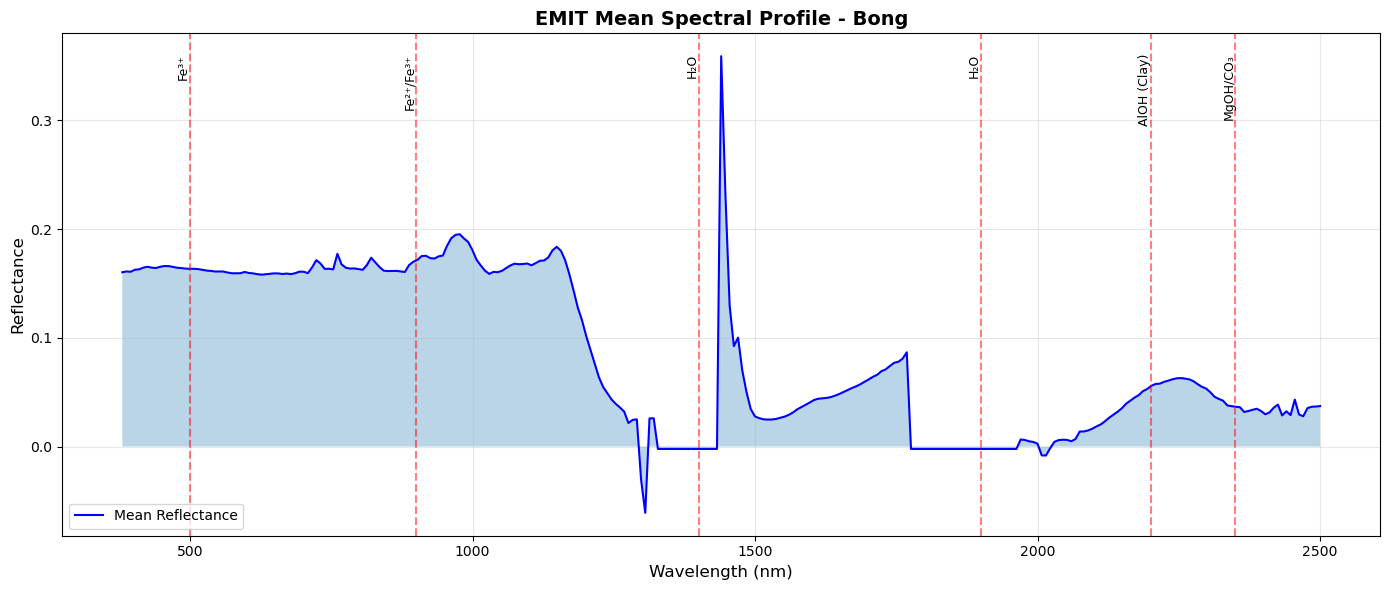

✅ Saved: spectral_profile_Bong.png


In [7]:
# Plot mean spectral profile
if cube is not None:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(wavelengths, mean_spectrum, 'b-', linewidth=1.5, label='Mean Reflectance')
    ax.fill_between(wavelengths, 0, mean_spectrum, alpha=0.3)
    
    # Mark key absorption features
    key_features = {
        500: 'Fe³⁺',
        900: 'Fe²⁺/Fe³⁺',
        1400: 'H₂O',
        1900: 'H₂O',
        2200: 'AlOH (Clay)',
        2350: 'MgOH/CO₃'
    }
    
    for wl, label in key_features.items():
        ax.axvline(x=wl, color='red', linestyle='--', alpha=0.5)
        ax.text(wl, ax.get_ylim()[1]*0.95, label, rotation=90, 
                fontsize=9, ha='right', va='top')
    
    ax.set_xlabel('Wavelength (nm)', fontsize=12)
    ax.set_ylabel('Reflectance', fontsize=12)
    ax.set_title(f'EMIT Mean Spectral Profile - {test_deposit}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/spectral_profile_{test_deposit}.png", dpi=150)
    plt.show()
    print(f"✅ Saved: spectral_profile_{test_deposit}.png")

## 3. Compare All Deposits

In [8]:
# Load and compare all deposits
deposit_names = ['Bong', 'Lai', 'Minh', 'Nam', 'Thanh', 'Yen']
full_names = {
    'Bong': 'Bồng Miêu (Quảng Nam)',
    'Lai': 'Lai Châu',
    'Minh': 'Minh Lương (Lào Cai)',
    'Nam': 'Nam Quang (Cao Bằng)',
    'Thanh': 'Thanh Hóa',
    'Yen': 'Yên Bái'
}

all_spectra = {}
all_stats = []

for name in deposit_names:
    cube, meta = load_emit_deposit(name)
    if cube is not None:
        spectrum = get_mean_spectrum(cube)
        all_spectra[name] = spectrum
        
        # Stats
        all_stats.append({
            'deposit': full_names[name],
            'bands': cube.shape[0],
            'height': cube.shape[1],
            'width': cube.shape[2],
            'mean_reflectance': np.nanmean(cube),
            'max_reflectance': np.nanmax(cube),
            'nan_ratio': np.isnan(cube).sum() / cube.size * 100
        })

stats_df = pd.DataFrame(all_stats)
print("\n📊 DEPOSIT STATISTICS:")
stats_df


📂 Loading Bong...
   ✅ Bands 000_069: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)

📂 Loading Lai...
   ✅ Bands 000_069: shape (70, 334, 359)
   ✅ Bands 070_139: shape (70, 334, 359)

📂 Loading Lai...
   ✅ Bands 000_069: shape (70, 334, 359)
   ✅ Bands 070_139: shape (70, 334, 359)
   ✅ Bands 140_209: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 334, 359)
   ✅ Bands 280_284: shape (5, 334, 359)
   📊 Total cube shape: (285, 334, 359) (bands, height, width)
   ✅ Bands 140_209: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 334, 359)
   ✅ Bands 280_284: shap

,deposit,bands,height,width,mean_reflectance,max_reflectance,nan_ratio
0,Bồng Miêu (Quảng Nam),285,335,345,0.084066,4.928712,0.0
1,Lai Châu,285,334,359,0.031439,2.418228,0.0
2,Minh Lương (Lào Cai),285,335,360,0.012831,1.065675,0.0
3,Nam Quang (Cao Bằng),285,335,361,0.235047,7.357143,0.0
4,Thanh Hóa,285,335,354,-9889.474609,4.601379,0.0
5,Yên Bái,285,335,358,-4563.110352,5.569237,0.0


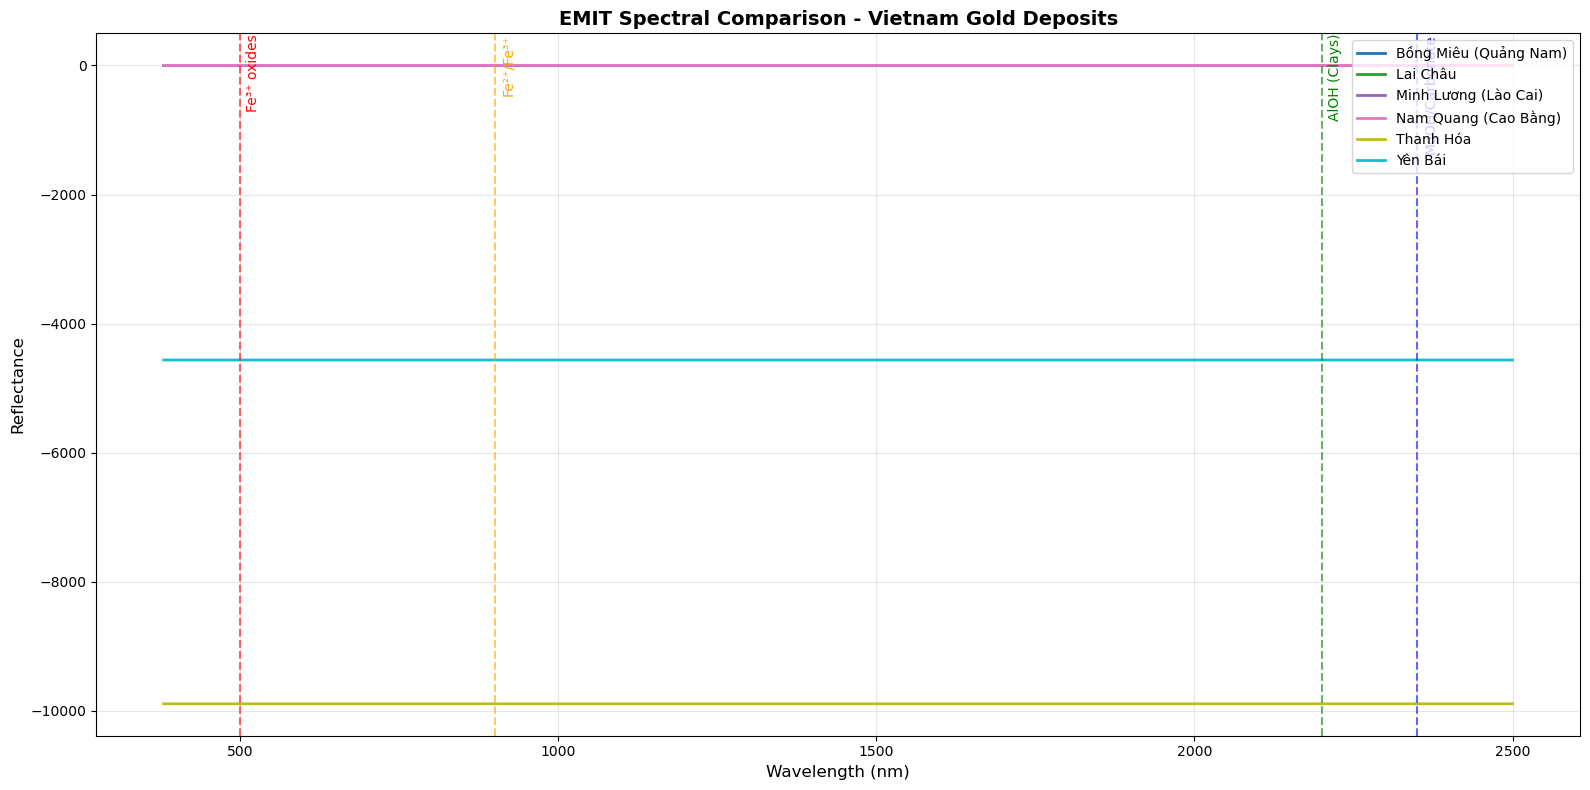

✅ Saved: spectral_comparison_all.png


In [9]:
# Plot all spectral profiles together
fig, ax = plt.subplots(figsize=(16, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_spectra)))

for (name, spectrum), color in zip(all_spectra.items(), colors):
    ax.plot(wavelengths[:len(spectrum)], spectrum, 
            linewidth=2, label=full_names[name], color=color)

# Key mineral absorption bands
mineral_bands = {
    500: ('Fe³⁺ oxides', 'red'),
    900: ('Fe²⁺/Fe³⁺', 'orange'),
    2200: ('AlOH (Clays)', 'green'),
    2350: ('MgOH/Carbonate', 'blue')
}

for wl, (label, color) in mineral_bands.items():
    ax.axvline(x=wl, color=color, linestyle='--', alpha=0.6, linewidth=1.5)
    ax.text(wl+10, ax.get_ylim()[1]*0.98, label, fontsize=10, 
            color=color, rotation=90, va='top')

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Reflectance', fontsize=12)
ax.set_title('EMIT Spectral Comparison - Vietnam Gold Deposits', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spectral_comparison_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: spectral_comparison_all.png")

## 4. RGB Composite Visualization

In [10]:
def create_rgb(cube, r_band=40, g_band=25, b_band=10):
    """Create RGB composite from hyperspectral cube"""
    r = cube[r_band]
    g = cube[g_band]
    b = cube[b_band]
    
    # Stack and normalize
    rgb = np.stack([r, g, b], axis=-1)
    
    # Handle NaN
    rgb = np.nan_to_num(rgb, 0)
    
    # Stretch to 0-1
    for i in range(3):
        band = rgb[:,:,i]
        p2, p98 = np.percentile(band[band > 0], [2, 98])
        rgb[:,:,i] = np.clip((band - p2) / (p98 - p2), 0, 1)
    
    return rgb

def create_false_color(cube, r_band=150, g_band=70, b_band=40):
    """Create SWIR false color composite"""
    return create_rgb(cube, r_band, g_band, b_band)


📂 Loading Bong...
   ✅ Bands 000_069: shape (70, 335, 345)
   ✅ Bands 000_069: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)

📂 Loading Lai...
   ✅ Bands 000_069: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)

📂 Loading Lai...
   ✅ Bands 000_069: shape (70, 334, 359)
   ✅ Bands 070_139: shape (70, 334, 359)
   ✅ Bands 140_209: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 334, 359)
   ✅ Bands 280_284: shape (5, 334, 359)
   ✅ Bands 070_139: shape (70, 334, 359)
   ✅ Bands 140_209: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 334, 359)
   ✅ Bands 280_284: shape (5, 334, 359)
   📊 

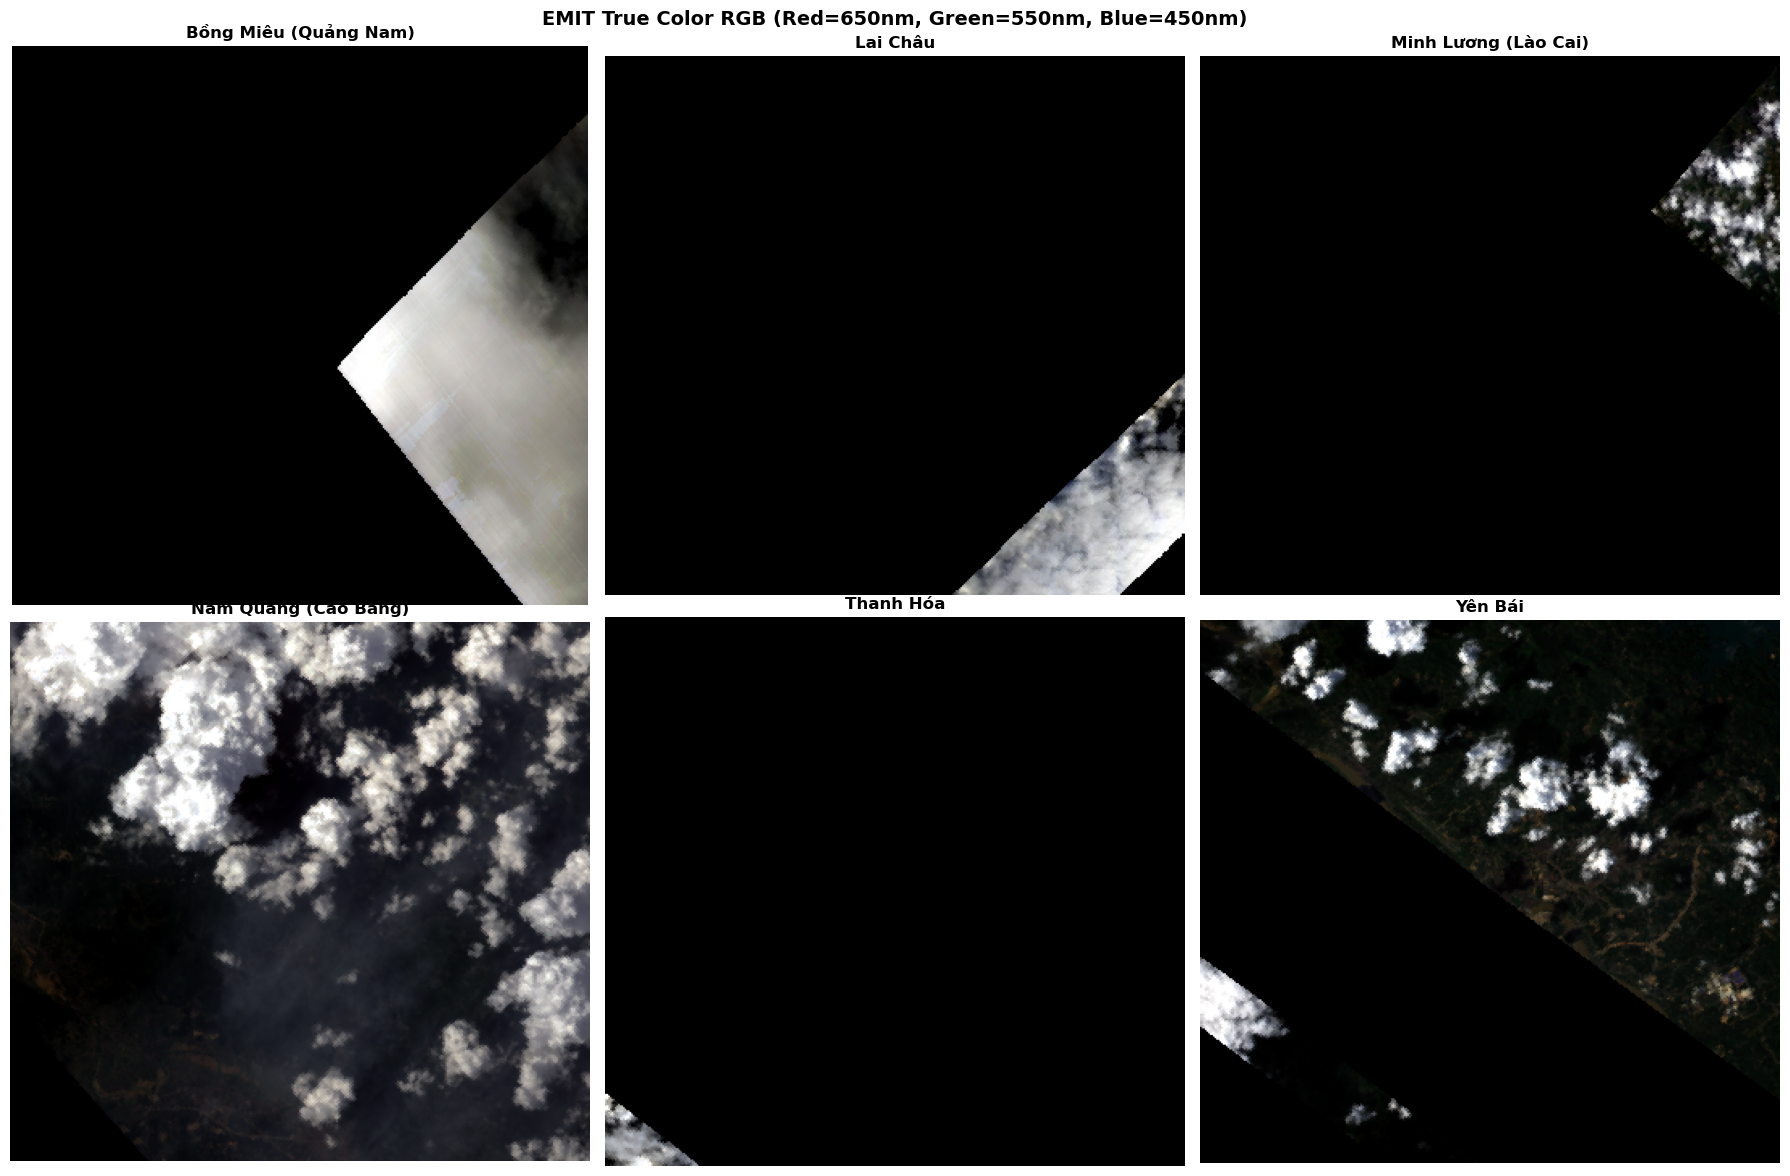

✅ Saved: rgb_composite_all.png


In [11]:
# Create RGB for all deposits
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, name in enumerate(deposit_names):
    cube, meta = load_emit_deposit(name)
    
    if cube is not None:
        rgb = create_rgb(cube)
        axes[idx].imshow(rgb)
        axes[idx].set_title(full_names[name], fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, 'No Data', ha='center', va='center')
        axes[idx].set_title(full_names[name])

plt.suptitle('EMIT True Color RGB (Red=650nm, Green=550nm, Blue=450nm)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rgb_composite_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rgb_composite_all.png")


📂 Loading Bong...
   ✅ Bands 000_069: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)

📂 Loading Lai...
   ✅ Bands 000_069: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)

📂 Loading Lai...
   ✅ Bands 000_069: shape (70, 334, 359)
   ✅ Bands 070_139: shape (70, 334, 359)
   ✅ Bands 140_209: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 334, 359)
   ✅ Bands 280_284: shape (5, 334, 359)
   ✅ Bands 070_139: shape (70, 334, 359)
   ✅ Bands 140_209: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 334, 359)
   ✅ Bands 280_284: shape (5, 334, 359)
   📊 Total cube shape: (285, 334, 359) (bands,

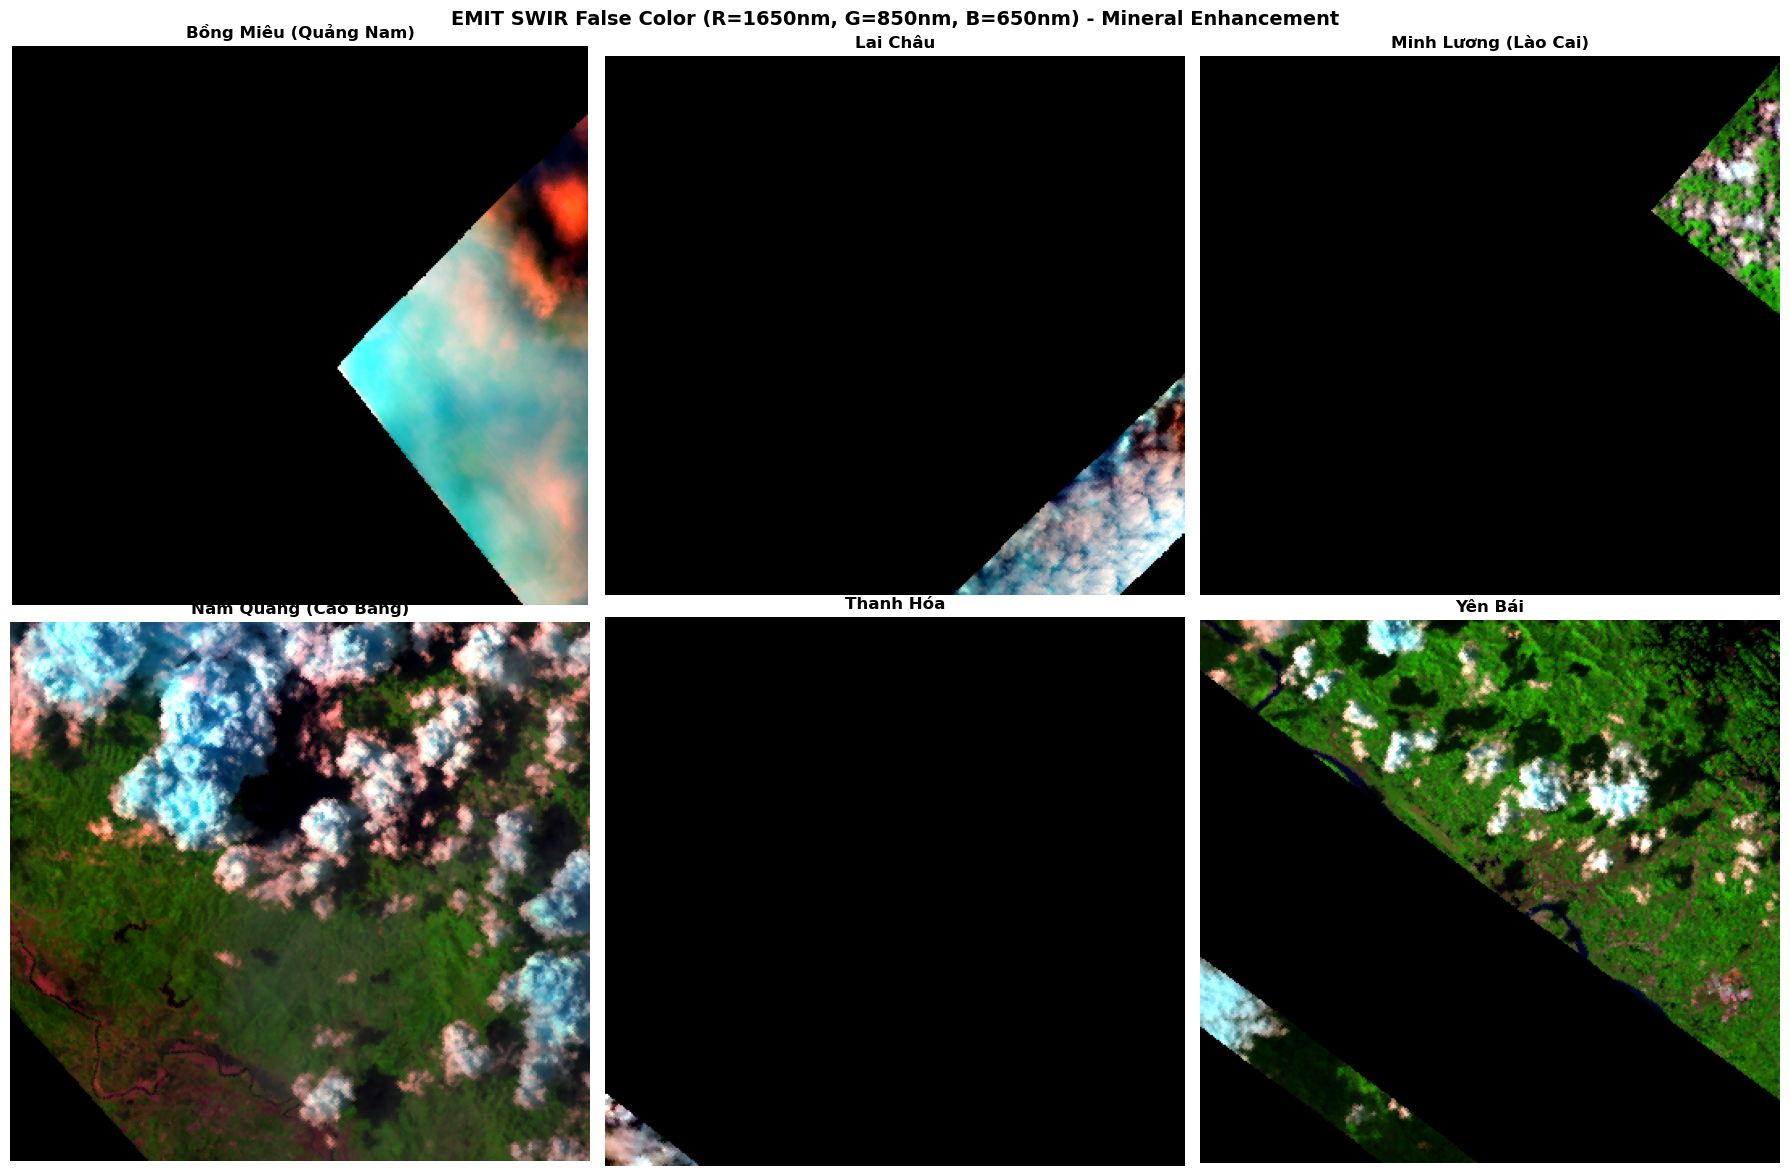

✅ Saved: swir_composite_all.png


In [12]:
# Create SWIR False Color for mineral detection
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, name in enumerate(deposit_names):
    cube, meta = load_emit_deposit(name)
    
    if cube is not None:
        # SWIR composite for minerals
        # R: ~1650nm (band 150), G: ~850nm (band 70), B: ~650nm (band 40)
        false_color = create_false_color(cube, r_band=150, g_band=70, b_band=40)
        axes[idx].imshow(false_color)
        axes[idx].set_title(full_names[name], fontsize=12, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('EMIT SWIR False Color (R=1650nm, G=850nm, B=650nm) - Mineral Enhancement', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/swir_composite_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: swir_composite_all.png")

## 5. Mineral Index Calculation

In [13]:
def calculate_mineral_indices(cube):
    """Calculate mineral indices from EMIT data"""
    
    # Band indices (approximate for 285 bands covering 380-2500nm)
    # Each band ~ 7.4nm
    
    indices = {}
    
    # 1. NDVI (vegetation)
    nir = cube[70]   # ~850nm
    red = cube[40]   # ~650nm
    indices['NDVI'] = (nir - red) / (nir + red + 1e-10)
    
    # 2. Ferric Iron Index (Fe³⁺)
    # Ratio of 650nm / 500nm
    b650 = cube[40]
    b500 = cube[20]
    indices['Ferric_Iron'] = b650 / (b500 + 1e-10)
    
    # 3. Ferrous Iron Index (Fe²⁺)
    b900 = cube[75]   # ~900nm
    b1000 = cube[90]  # ~1000nm
    indices['Ferrous_Iron'] = b900 / (b1000 + 1e-10)
    
    # 4. Clay Mineral Index (AlOH absorption at 2200nm)
    b2165 = cube[200]  # ~2165nm
    b2200 = cube[210]  # ~2200nm
    b2250 = cube[220]  # ~2250nm
    indices['Clay_2200'] = (b2165 + b2250) / (2 * b2200 + 1e-10)
    
    # 5. Carbonate Index (CO3 absorption at 2350nm)
    b2300 = cube[230]  # ~2300nm
    b2350 = cube[243]  # ~2350nm
    b2400 = cube[255]  # ~2400nm
    indices['Carbonate'] = (b2300 + b2400) / (2 * b2350 + 1e-10)
    
    # 6. Gossan Index (iron oxide weathering)
    b600 = cube[35]
    b500 = cube[20]
    b800 = cube[65]
    indices['Gossan'] = (b600 - b500) / (b800 + 1e-10)
    
    return indices

print("✅ Mineral index functions defined")

✅ Mineral index functions defined


In [14]:
# Calculate indices for one deposit
test_name = 'Nam Quang'  # Top gold prospect
cube, meta = load_emit_deposit(test_name)

if cube is not None:
    indices = calculate_mineral_indices(cube)
    
    # Plot all indices
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    cmaps = {
        'NDVI': 'RdYlGn',
        'Ferric_Iron': 'Reds',
        'Ferrous_Iron': 'Oranges',
        'Clay_2200': 'YlOrBr',
        'Carbonate': 'Blues',
        'Gossan': 'hot'
    }
    
    for idx, (name, data) in enumerate(indices.items()):
        # Clean data
        data = np.nan_to_num(data, 0)
        vmin, vmax = np.percentile(data[data != 0], [2, 98])
        
        im = axes[idx].imshow(data, cmap=cmaps[name], vmin=vmin, vmax=vmax)
        axes[idx].set_title(name, fontsize=12, fontweight='bold')
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    
    plt.suptitle(f'Mineral Indices - {full_names[test_name]} (Top Gold Prospect)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/mineral_indices_{test_name}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: mineral_indices_{test_name}.png")

❌ No files found for Nam Quang


## 6. Gold Prospectivity Map

In [15]:
def calculate_gold_prospectivity(cube):
    """Calculate gold prospectivity score from mineral indices"""
    
    indices = calculate_mineral_indices(cube)
    
    # Normalize each index to 0-1
    normalized = {}
    for name, data in indices.items():
        data = np.nan_to_num(data, 0)
        if data.max() > data.min():
            normalized[name] = (data - data.min()) / (data.max() - data.min())
        else:
            normalized[name] = data
    
    # Weighted combination for gold
    # High weight: Gossan (surface expression), Ferric (iron oxides)
    # Medium weight: Clay (alteration), Carbonate
    # Low NDVI indicates exposed rock
    
    prospectivity = (
        0.25 * normalized['Gossan'] +
        0.25 * normalized['Ferric_Iron'] +
        0.20 * normalized['Clay_2200'] +
        0.15 * normalized['Carbonate'] +
        0.15 * (1 - normalized['NDVI'])  # Low vegetation = exposed rock
    )
    
    return prospectivity

print("✅ Gold prospectivity function defined")

✅ Gold prospectivity function defined



📂 Loading Bong...
   ✅ Bands 000_069: shape (70, 335, 345)
   ✅ Bands 000_069: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 070_139: shape (70, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   ✅ Bands 140_209: shape (70, 335, 345)
   ✅ Bands 210_279: shape (70, 335, 345)
   ✅ Bands 280_284: shape (5, 335, 345)
   📊 Total cube shape: (285, 335, 345) (bands, height, width)

📂 Loading Lai...
   📊 Total cube shape: (285, 335, 345) (bands, height, width)

📂 Loading Lai...
   ✅ Bands 000_069: shape (70, 334, 359)
   ✅ Bands 070_139: shape (70, 334, 359)
   ✅ Bands 000_069: shape (70, 334, 359)
   ✅ Bands 070_139: shape (70, 334, 359)
   ✅ Bands 140_209: shape (70, 334, 359)
   ✅ Bands 140_209: shape (70, 334, 359)
   ✅ Bands 210_279: shape (70, 334, 359)
   ✅ Bands 280_284: shape (5, 334, 359)
   📊 Total cube shape: (285, 334, 359) (bands, height, width)

📂 Loading Minh...
   ✅ 

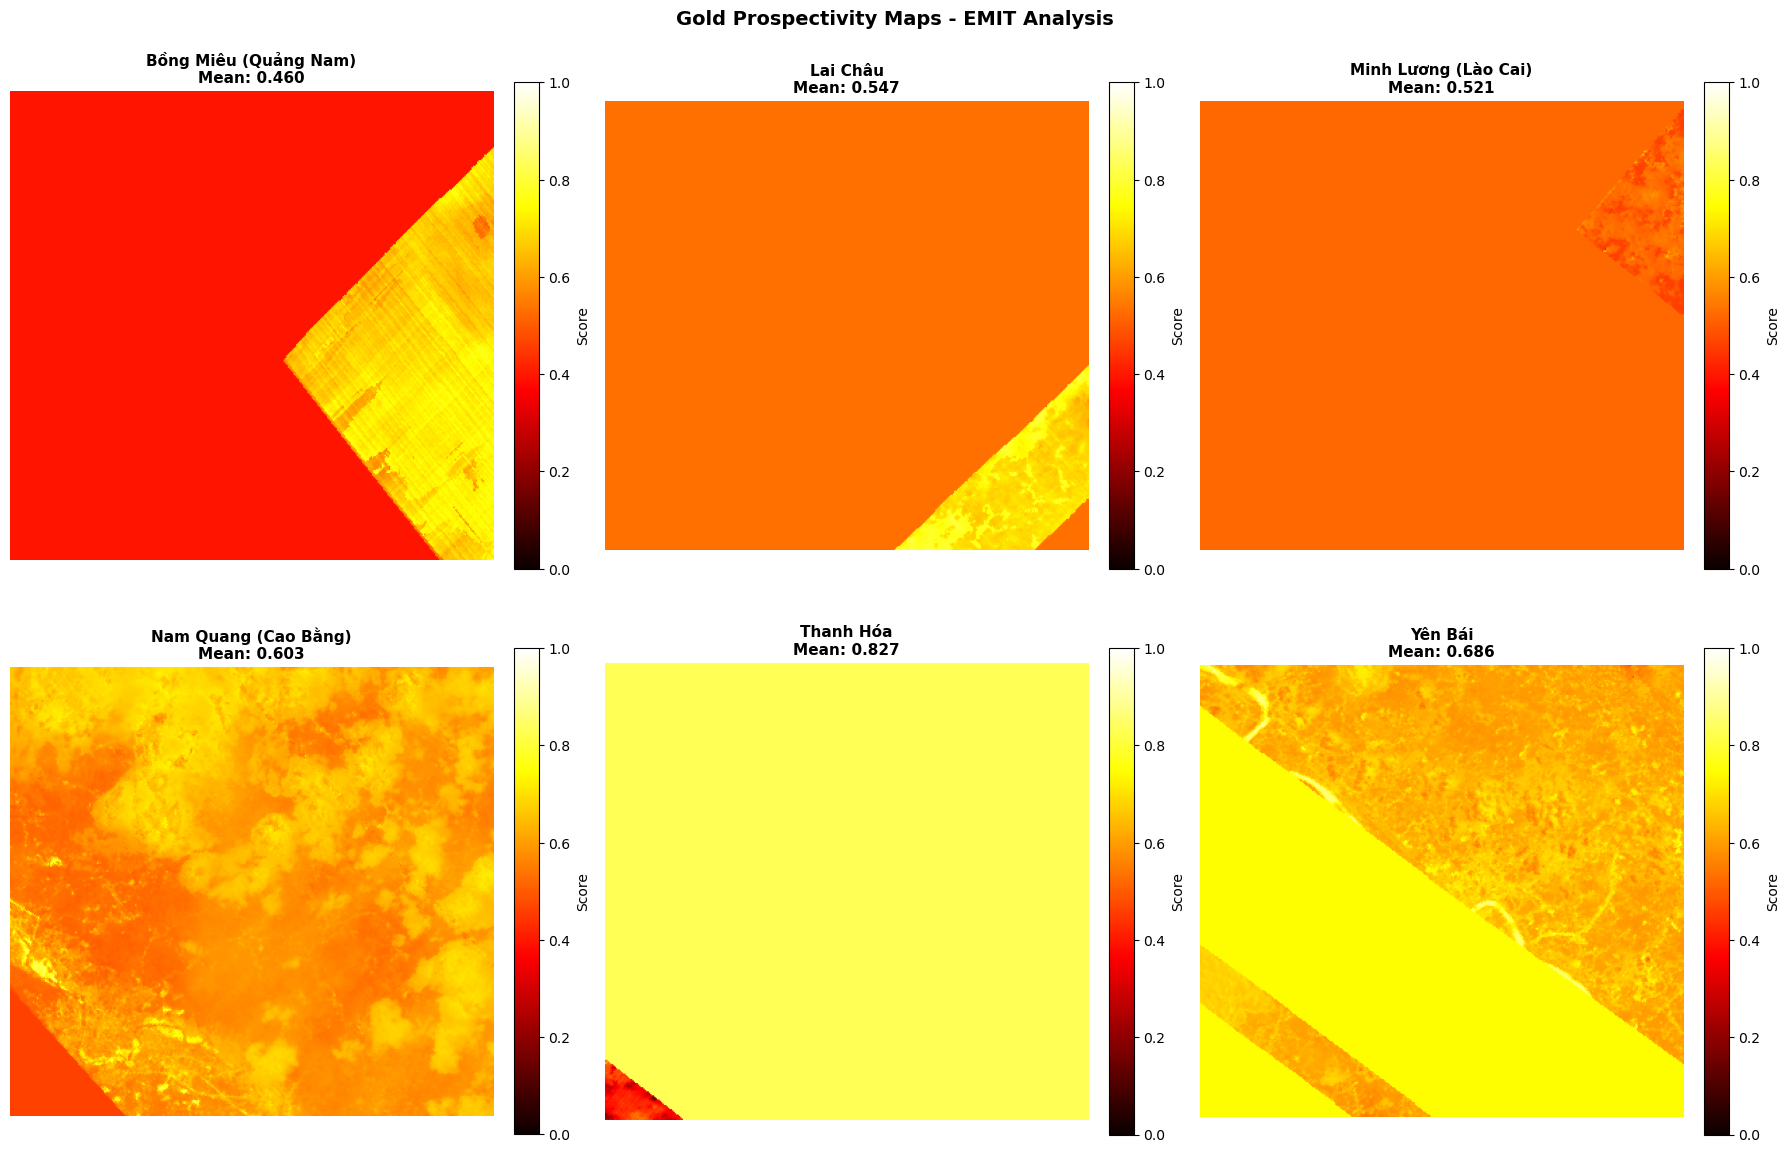


🏆 GOLD PROSPECTIVITY RANKING:


,deposit,mean_score,max_score,high_potential_pct
4,Thanh Hóa,0.826501,0.831221,98.900413
5,Yên Bái,0.685801,0.887376,47.984658
3,Nam Quang (Cao Bằng),0.603283,0.883479,2.274776
1,Lai Châu,0.547470,0.827904,3.965606
2,Minh Lương (Lào Cai),0.521407,0.705920,0.000829
0,Bồng Miêu (Quảng Nam),0.460111,0.789592,10.144928


In [16]:
# Calculate gold prospectivity for all deposits
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

prospectivity_stats = []

for idx, name in enumerate(deposit_names):
    cube, meta = load_emit_deposit(name)
    
    if cube is not None:
        prosp = calculate_gold_prospectivity(cube)
        
        # Stats
        prospectivity_stats.append({
            'deposit': full_names[name],
            'mean_score': np.nanmean(prosp),
            'max_score': np.nanmax(prosp),
            'high_potential_pct': (prosp > 0.7).sum() / prosp.size * 100
        })
        
        # Plot
        im = axes[idx].imshow(prosp, cmap='hot', vmin=0, vmax=1)
        axes[idx].set_title(f"{full_names[name]}\nMean: {np.nanmean(prosp):.3f}", 
                           fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label='Score')

plt.suptitle('Gold Prospectivity Maps - EMIT Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/gold_prospectivity_maps.png", dpi=150, bbox_inches='tight')
plt.show()

# Show stats
prosp_df = pd.DataFrame(prospectivity_stats)
prosp_df = prosp_df.sort_values('mean_score', ascending=False)
print("\n🏆 GOLD PROSPECTIVITY RANKING:")
prosp_df

## 7. Summary Statistics

In [17]:
# Combine all statistics
summary_df = pd.merge(stats_df, prosp_df, on='deposit')

print("\n" + "="*70)
print("📊 COMPLETE EMIT EDA SUMMARY")
print("="*70)
print(f"\nTotal deposits analyzed: {len(summary_df)}")
print(f"Total bands per image: ~285")
print(f"Wavelength range: 380-2500 nm")

print("\n" + summary_df.to_string())

# Save summary
summary_df.to_csv(f"{OUTPUT_DIR}/emit_eda_summary.csv", index=False)
print(f"\n✅ Summary saved to: {OUTPUT_DIR}/emit_eda_summary.csv")


📊 COMPLETE EMIT EDA SUMMARY

Total deposits analyzed: 6
Total bands per image: ~285
Wavelength range: 380-2500 nm

                 deposit  bands  height  width  mean_reflectance  max_reflectance  nan_ratio  mean_score  max_score  high_potential_pct
0  Bồng Miêu (Quảng Nam)    285     335    345          0.084066         4.928712        0.0    0.460111   0.789592           10.144928
1               Lai Châu    285     334    359          0.031439         2.418228        0.0    0.547470   0.827904            3.965606
2   Minh Lương (Lào Cai)    285     335    360          0.012831         1.065675        0.0    0.521407   0.705920            0.000829
3   Nam Quang (Cao Bằng)    285     335    361          0.235047         7.357143        0.0    0.603283   0.883479            2.274776
4              Thanh Hóa    285     335    354      -9889.474609         4.601379        0.0    0.826501   0.831221           98.900413
5                Yên Bái    285     335    358      -4563.110352    

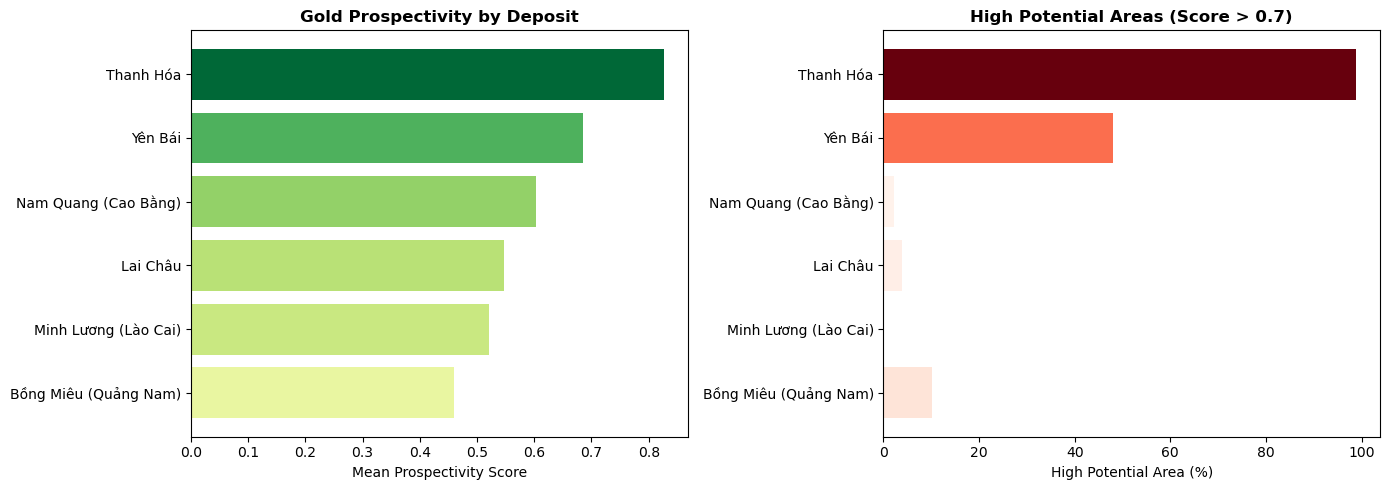


🏆 TOP 3 GOLD PROSPECTS:
   1. Thanh Hóa: Score = 0.8265
   2. Yên Bái: Score = 0.6858
   3. Nam Quang (Cao Bằng): Score = 0.6033


: 

In [ ]:
# Final visualization - bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by mean score
sorted_df = summary_df.sort_values('mean_score', ascending=True)

# Mean prospectivity score
colors = plt.cm.RdYlGn(sorted_df['mean_score'] / sorted_df['mean_score'].max())
axes[0].barh(sorted_df['deposit'], sorted_df['mean_score'], color=colors)
axes[0].set_xlabel('Mean Prospectivity Score')
axes[0].set_title('Gold Prospectivity by Deposit', fontweight='bold')

# High potential percentage
colors2 = plt.cm.Reds(sorted_df['high_potential_pct'] / sorted_df['high_potential_pct'].max())
axes[1].barh(sorted_df['deposit'], sorted_df['high_potential_pct'], color=colors2)
axes[1].set_xlabel('High Potential Area (%)')
axes[1].set_title('High Potential Areas (Score > 0.7)', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/prospectivity_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n🏆 TOP 3 GOLD PROSPECTS:")
top3 = summary_df.nlargest(3, 'mean_score')
for i, row in enumerate(top3.itertuples(), 1):
    print(f"   {i}. {row.deposit}: Score = {row.mean_score:.4f}")

## ✅ EDA Complete!

### Outputs saved:
- `spectral_profile_*.png` - Spectral profiles
- `spectral_comparison_all.png` - All deposits comparison
- `rgb_composite_all.png` - True color images
- `swir_composite_all.png` - SWIR mineral composites
- `mineral_indices_*.png` - Mineral index maps
- `gold_prospectivity_maps.png` - Prospectivity maps
- `prospectivity_comparison.png` - Ranking charts
- `emit_eda_summary.csv` - Summary statistics